In [102]:
import pandas as pd 

import matplotlib.pyplot as plt #MATPLOTLIB FOR VISUALISATION
from mplsoccer import VerticalPitch #PITCH GRAPHIC

In [103]:
df = pd.read_csv('erling_haaland_2022_understat.csv')
df.head() 

,id,minute,result,X,Y,xG,player,h_a,player_id,situation,season,shotType,match_id,h_team,a_team,h_goals,a_goals,date,player_assisted,lastAction
0,479846,20,MissedShots,0.936,0.503,0.484085,Erling Haaland,a,8260,OpenPlay,2022,Head,18211,West Ham,Manchester City,0,2,2022-08-07 15:30:00,Phil Foden,Cross
1,479847,35,Goal,0.885,0.500,0.761169,Erling Haaland,a,8260,Penalty,2022,LeftFoot,18211,West Ham,Manchester City,0,2,2022-08-07 15:30:00,NaN,Standard
2,479854,64,Goal,0.864,0.405,0.328053,Erling Haaland,a,8260,OpenPlay,2022,LeftFoot,18211,West Ham,Manchester City,0,2,2022-08-07 15:30:00,Kevin De Bruyne,Throughball
3,479855,69,MissedShots,0.953,0.552,0.526608,Erling Haaland,a,8260,OpenPlay,2022,Head,18211,West Ham,Manchester City,0,2,2022-08-07 15:30:00,Jack Grealish,Chipped
4,479856,75,BlockedShot,0.894,0.710,0.066443,Erling Haaland,a,8260,OpenPlay,2022,LeftFoot,18211,West Ham,Manchester City,0,2,2022-08-07 15:30:00,Ilkay Gündogan,Pass


In [104]:
#UNDERSTAT COORDINATES SCALED TO 0-1 WHILE MPLSOCCER PITCH IS 0-100

df['X'] = df['X'] * 100
df['Y'] = df['Y'] * 100

In [105]:
#DESCRPTIVE STATS

total_shots = df.shape[0] 
total_goals = df[df['result'] == 'Goal'].shape[0]
total_xG = df['xG'].sum()
xG_per_shot = total_xG / total_shots

In [106]:
#AVERAGE SHOT DISTANCE

points_average_distance = df['X'].mean()
actual_average_distance = 120 - (df['X'] * 1.2).mean() 

In [107]:
#BACKGROUND COLOUR

background_color = '#0C0D0E'

In [108]:
#FONT

import matplotlib.font_manager as font_manager

font_path = 'Roboto-Regular.ttf'
font_props = font_manager.FontProperties(fname=font_path)

Text(0.75, 0, '0.27')

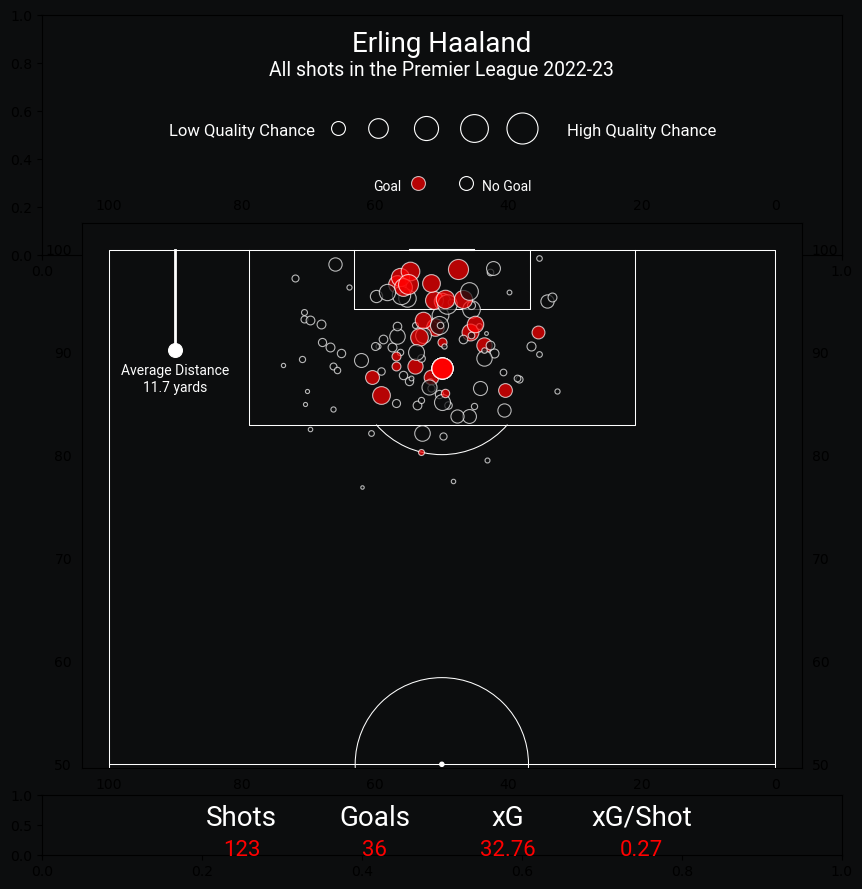

In [109]:
#GRAPHIC

fig = plt.figure(figsize=(8,12)) #CREATES GRAPHIC 
fig.patch.set_facecolor(background_color) #GRAPHIC BACKGROUND COLOUR

#GRAPHIC PART 1 (TOP SECTION)

ax1 = fig.add_axes([0, .7, 1, .2]) #CREATES A GRID FOR SECTION 1 OF OUR GRAPHIC
ax1.set_facecolor(background_color) #MAKES THE GRID COLOR BLEND IN WITH THE GRAPHIC BACKGROUND COLOUR

ax1.set_xlim(0,1) #SETS THE LIMITS OF X & Y AXIS FROM 0-1 (ANY DATA OUTSIDE OF THIS WILL NOT BE DISPLAYED) 
ax1.set_ylim(0,1)

ax1.text(
    x=.5,
    y=.85,
    s='Erling Haaland',
    fontsize=20,
    fontproperties=font_props,
    fontweight='bold',
    color='white',
    ha='center'
)

ax1.text(
    x=.5,
    y=.75,
    s='All shots in the Premier League 2022-23',
    fontsize=14,
    fontproperties=font_props,
    fontweight='bold',
    color='white',
    ha='center'
)

ax1.text(
    x=.25,
    y=.5,
    s='Low Quality Chance',
    fontsize=12,
    fontproperties=font_props,
    fontweight='bold',
    color='white',
    ha='center'
)

ax1.scatter(
    x=.37,
    y=.53,
    s=100,
    color=background_color,
    edgecolor='white',
    linewidth=.8
)

ax1.scatter(
    x=.42,
    y=.53,
    s=200,
    color=background_color,
    edgecolor='white',
    linewidth=.8
)

ax1.scatter(
    x=.48,
    y=.53,
    s=300,
    color=background_color,
    edgecolor='white',
    linewidth=.8
)

ax1.scatter(
    x=.54,
    y=.53,
    s=400,
    color=background_color,
    edgecolor='white',
    linewidth=.8
)

ax1.scatter(
    x=.6,
    y=.53,
    s=500,
    color=background_color,
    edgecolor='white',
    linewidth=.8
)

ax1.text(
    x=.75,
    y=.5,
    s='High Quality Chance',
    fontsize=12,
    fontproperties=font_props,
    fontweight='bold',
    color='white',
    ha='center'
)

ax1.text(
    x=.45,
    y=.27,
    s='Goal',
    fontsize=10,
    fontproperties=font_props,
    color='white',
    ha='right'
)

ax1.scatter(
    x=.47,
    y=.3,
    s=100,
    color='red',
    edgecolor='white',
    linewidth=.8,
    alpha=.7
)

ax1.scatter(
    x=.53,
    y=.3,
    s=100,
    color=background_color,
    edgecolor='white',
    linewidth=.8
)

ax1.text(
    x=.55,
    y=.27,
    s='No Goal',
    fontsize=10,
    fontproperties=font_props,
    color='white',
    ha='left'
)

#GRAPHIC PART 2 (PITCH SECTION)

ax2 = fig.add_axes([.05, .25, .9, .5]) #CREATES A GRID FOR SECTION 2 OF OUR GRAPHIC
ax2.set_facecolor(background_color) #MAKES THE GRID COLOR BLEND IN WITH THE GRAPHIC BACKGROUND COLOUR

pitch = VerticalPitch(
    pitch_type='opta',
    half=True,
    pitch_color=background_color,
    pad_bottom=.5,
    line_color='white',
    linewidth=.75,
    axis=True,
    label=True
)

pitch.draw(ax=ax2) #DRAWS PITCH ONTO SECTION 2 OF THE GRAPHIC

#CREATE AVERAGE DISTANCE VISUALISATION

ax2.scatter(x=90,
            y=points_average_distance,
            s=100,
            color='white',
            linewidth=.8)

ax2.plot([90, 90], [100, points_average_distance], color='white', linewidth=2)

ax2.text(
    x=90,
    y= points_average_distance -4,
    s=f'Average Distance\n{actual_average_distance:.1f} yards',
    fontsize=10,
    fontproperties=font_props,
    color='white',
    ha = 'center'
)
    
#PLOT DATA FROM DATAFRAME 

for x in df.to_dict(orient='records'): #LOOP THROUGH A DICTIONARY RATHER THAN DATAFRAME
    pitch.scatter(
        x['X'],
        x['Y'],
        s=300 * x['xG'], #SCALE PLOTS BASED ON XG VALUE
        color = 'red' if x['result'] == 'Goal' else background_color,
        ax=ax2,
        alpha = .7,
        linewidth=.8,
        edgecolor='white'
    )
    
#GRAPHIC PART 3 (DESCRIPTIVE STATS)

ax3 = fig.add_axes([0, .2, 1, .05]) #CREATES A GRID FOR SECTION 3 OF OUR GRAPHIC
ax3.set_facecolor(background_color) #MAKES THE GRID COLOR BLEND IN WITH THE GRAPHIC BACKGROUND COLOUR

ax3.text(x=.25, 
         y=.5,
         s='Shots',
         fontsize=20,
         fontproperties=font_props,
         fontweight='bold',
         color='white',
         ha='center'
        )

ax3.text(x=.25, 
         y=0,
         s=f'{total_shots}',
         fontsize=16,
         fontproperties=font_props,
         color='red',
         ha='center'
        )

ax3.text(x=.416, 
         y=.5,
         s='Goals',
         fontsize=20,
         fontproperties=font_props,
         fontweight='bold',
         color='white',
         ha='center'
        )

ax3.text(x=.416, 
         y=0,
         s=f'{total_goals}',
         fontsize=16,
         fontproperties=font_props,
         color='red',
         ha='center'
        )

ax3.text(x=.583, 
         y=.5,
         s='xG',
         fontsize=20,
         fontproperties=font_props,
         fontweight='bold',
         color='white',
         ha='center'
        )

ax3.text(x=.583, 
         y=0,
         s=f'{total_xG:.2f}',
         fontsize=16,
         fontproperties=font_props,
         color='red',
         ha='center'
        )

ax3.text(x=.75, 
         y=.5,
         s='xG/Shot',
         fontsize=20,
         fontproperties=font_props,
         fontweight='bold',
         color='white',
         ha='center'
        )

ax3.text(x=.75, 
         y=0,
         s=f'{xG_per_shot:.2f}',
         fontsize=16,
         fontproperties=font_props,
         color='red',
         ha='center'
        )
